In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = [10, 6]

# Set pandas display options to show all columns for .head command
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)       # Auto-detect the display width
pd.set_option('display.max_colwidth', None)  # Show full content of each column

# 1. Motivation

The story we wanted to tell was about the mortality crisis in Russia, how it relates to alcohol consumption, why it mostly affects working men and how new laws and other government actions have been able to combat this. We combined multiple dataset since we found using only one would not be possible to get all the information and context needed for the story.

Our datasets are:

* Results from a 2021 study on the Global Burden of Disease (GBD) https://vizhub.healthdata.org/gbd-results?params=gbd-api-2021-permalink/e536e88427a28a4e136289ad19ec6c0b. This dataset provides annual cause-specific mortality data globally, including metrics such as number of deaths, death rates, and Years of Life Lost (YLLs). We filtered this data by country (Russia and others), sex, and causes of death  This dataset was chosen because it contains mortality data over the whole period we wanted to look at (the past 30 years) for all the countries the world. The data can be filtered by causes of death specifically related to alcohol (including alcoholic liver disease, alcohol use disorders, alcoholic cardiomyopathy, and alcohol-attributable cancers) along with sex, age and country. This data was used to compare the alcohol-related mortality in Russia to the rest of the world. It was also used to compare Years of Life Lost due to alcohol-related mortality in Russia between the sexes.
* The Russian Fertility and Mortality database (RusFMD) of the Centre of Demographic Research of the New Economic School (CDR NES) (https://www.nes.ru/demogr-fermort-data?lang=en). Contains detailed mortality data about with groupings by cause of death, region, year, age, gender and urban/rural areas
* Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol), by beverage type, WHO (https://www.who.int/data/gho/data/indicators/indicator-details/GHO/alcohol-recorded-per-capita-(15-)-consumption-(in-litres-of-pure-alcohol)). Contains alcohol consumption by beverage type, used to compare alcohol consumption to mortality
* Human Mortality Database (2024) UN, World Population Prospects (2024) – with major processing by Our World in Data (https://ourworldindata.org/grapher/difference-in-female-and-male-life-expectancy-at-birth?tab=chart&country=~RUS). Used to emphasize that men are mostly targeted by the mortality crisis
* "Demand for Alcohol Consumption in Russia and Its Implication for Mortality" (regional_level_data.dta). Used for regional-level alcohol price data by year https://www.openicpsr.org/openicpsr/project/113586/version/V1/view?path=/openicpsr/113586/fcr:versions/V1/Replication_files/Data&type=folder.
* "The Long-Run Effects of a Public Policy on Alcohol Tates and Mortality" (regional_data_12may2017.dta). Contains alcohol sales volumes by beverage and beverage shares over time https://www.openicpsr.org/openicpsr/project/117443/version/V1/view
* Russia GeoJSON shape file. Used for mapping regional and federal patterns.

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Basic stats. Let's understand the dataset better

### Global Burden of Disease data

The GBD data contains global health statistics and offers a lot of dimension: Cause (e.g., alcohol use disorders, total cancers), Measure (e.g., YLLs, deaths), Metric (e.g., rate, number), Location (e.g., national level: Russia), Age (e.g., specific years or grouped categories), Sex (male, female), Year (annual data available from 1980 to 2021). 

The data was queried online https://vizhub.healthdata.org/gbd-results/, producing a few different csv files that were then further processed. We started by querying the data by Cause: all, Metric: number, Location: Russia, Age: all, Year: 1990-2021. This was used to plot the causes of death in Russia over the years. The top 8 causes of death were selected (because a larger number made the plot hard to read), then the four alcohol-related causes (alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use) were grouped as one cause and plotted along with the others for comparison.

<Figure size 1400x600 with 0 Axes>

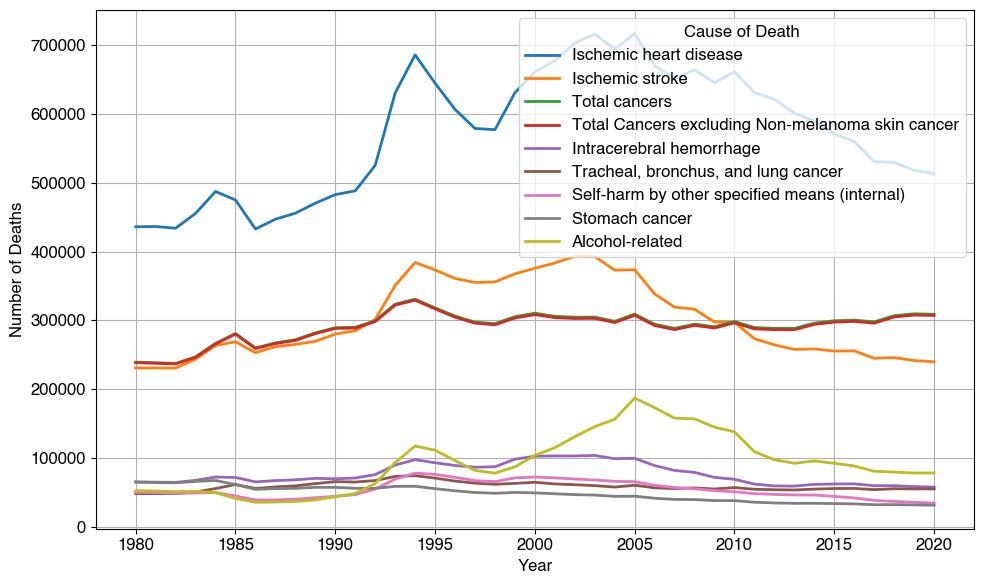

In [75]:
df = pd.read_csv("assets/data/cod_russia.csv" )

filtered_df = df[
    (df['measure'] == 'Deaths') &
    (df['sex'] == 'Both') &
    (df['age'] == 'All ages')
]

pivot_df = filtered_df.pivot_table(index='year', columns='cause', values='val', aggfunc='sum')

alcohol_causes = [
    'Alcohol use disorders',
    'Alcoholic cardiomyopathy',
    'Cirrhosis due to alcohol',
    'Liver cancer due to alcohol use'
]

pivot_df['Alcohol-related'] = pivot_df[alcohol_causes].sum(axis=1)

pivot_df_reduced = pivot_df.drop(columns=[col for col in alcohol_causes if col in pivot_df.columns])

top_non_alcohol_causes_8 = (
    pivot_df_reduced.drop(columns='Alcohol-related')
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plot_df = pivot_df_reduced[list(top_non_alcohol_causes_8) + ['Alcohol-related']]

plt.figure(figsize=(14, 6))
plot_df.plot(kind='line', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend(title='Cause of Death', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


After looking at all the different causes, we queryed the data by Cause: alcohol-related causes (alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use), Measure: death, YLLs, Metric: rate, Location: all countries, Age: all, Sex: all, Year: 1990, 2000, 2010, 2020. We grouped the alcohol-related causes together as one, and found the total mortality rate for each country. The top 10 countries with the highest mortality in the selected years were looked at. 

In [76]:
df = pd.read_csv("assets/data/global-alcohol-deaths.csv")

deaths_df = df[df['measure'] == 'Deaths']
ylls_df = df[df['measure'].str.contains('YLL')]

top_deaths_unique = deaths_df.sort_values(by='val', ascending=False).drop_duplicates(subset='location').head(10)
top_ylls_unique = ylls_df.sort_values(by='val', ascending=False).drop_duplicates(subset='location').head(10)

top_death_countries = top_deaths_unique['location'].tolist()
top_yll_countries = top_ylls_unique['location'].tolist()

print("Top 10 countries by deaths of alcohol-related diseases:")
count=1
for country in top_death_countries:
    print("{}. {}".format(count, country) )
    count+=1

print("\nTop 10 countries by YLLs (Years of Life Lost) by alcohol-related diseases:")
count=1
for country in top_yll_countries:
    print("{}. {}".format(count, country) )
    count+=1

Top 10 countries by deaths of alcohol-related diseases:
1. Russian Federation
2. Republic of Moldova
3. Belarus
4. Hungary
5. Latvia
6. Romania
7. Ukraine
8. Estonia
9. Greenland
10. Mongolia

Top 10 countries by YLLs (Years of Life Lost) by alcohol-related diseases:
1. Russian Federation
2. Republic of Moldova
3. Belarus
4. Hungary
5. Ukraine
6. Latvia
7. Estonia
8. Mongolia
9. Greenland
10. Romania


Finally, it was decided to query the data by Cause: alcohol-related causes (alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use), Measure: death, Metric: rate, Location: Russia, Denmark, China, United States, France, Belarus, Age: all, Sex: all, Year: 1990-2020. This file is 97KB and was used to create a visualization putting Russian alcohol-related mortality rates in global context. It was also queryed by Cause: alcohol-related causes (alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use), Metric: YLLs, Location: Russia, Age: all, Sex: Male/Female, Year: 1990-2020. This file is 40KB and was used to create a visualization showing the Years of Life Lost between men and women in Russia.

### Russian mortality database
We worked with several datasets from this database, as the mortality data was usually split by 2 intervals 1989-2014 and 2012-2022 (overlap because the 2012-2022 was updated to use the most recent census). Generally the datasets fall into 2 groups:
- Mortality rates by age and sex: Russia and regions, one-year age groups (+ population data that was used to calculate the death rates)
- Mortality rates by age and sex: Russia and regions, causes of death, 5-year age groups (+ population data that was used to calculate the death rates)

The main work was merging the datasets for 2 different periods and combining it with the population data (so that the grouped death rates can be correctly calculated). There was a lot of mapping work because the causes of death were in ID format specific to the dataset, so they had to be mapped to values that we could use (pdf files with the values and their explanations was provided with the dataset).

For the mortality datasets we are interested in the period after 1990 so we have taken datasets that contain this period. The biggest obstacle is that causes of death were tracked by standards that changed a few times during this period, so the mapping is quite verbose and tiresome to do to find the correct causes in the correct periods. Because of this we decided to only consider alcohol related deaths and compare it some other cause of death. The mortality data is available only in 5 year age groups, so for the working age analysis we use the 20-64 range. The data contains the information about year, gender, region, and if the area is urban or rural.

In [77]:
# Considering ages 20 - 64 (they are divided into 5 year groups)
age_considered = range(20, 61, 5)
pop_cols = [f"PopD5a{age}" for age in age_considered]
death_cause_cols = [f"Drac{age}" for age in age_considered]
death_rate_cols = [f"DrAa{age}" for age in age_considered]
columns_cause = ['Year', 'Reg', 'Group', 'Sex', 'Cause_Type'] + death_cause_cols + pop_cols
columns_total = ['Year', 'Reg', 'Group', 'Sex'] + death_rate_cols + pop_cols

In [78]:
# Load population 5 age groups
df_pop1 = pd.read_csv('data/mortality_cause/population/PopD5a1989-2014.txt')
df_pop1 = df_pop1[df_pop1['Year'] < 2012]
df_pop2 = pd.read_csv('data/mortality_cause/population/PopD5a2012-2022.txt')

df_pop_5 = pd.concat([df_pop1, df_pop2], ignore_index=True)

In [79]:
# Death rates for 5 year groups
df1 = pd.read_csv('data/mortality_cause/total_5_year_group/DR5a1989-2014.txt')
df1 = df1[df1['Year'] < 2012]
df2 = pd.read_csv('data/mortality_cause/total_5_year_group/DR5a2012-2022.txt')

df_total = pd.concat([df1, df2], ignore_index=True)

df_total = pd.merge(
    df_total,
    df_pop_5,
    on=['Year', 'Reg', 'Group', 'Sex'],
    suffixes=('_death', '_population'),
    indicator=True  # this adds a column showing where each row came from
)

In [80]:
# --- Cause Codes for Different Periods (Simplified) ---

# Nomenclature based on ICD9 (used for "1989-1998" period)
alcohol_codes_icd9 = [
    73, # Alcoholic psychosis
    75, # Chronic alcoholism
    163 # Accidental poisoning by alcohol
]
circulatory_codes_icd9 = list(range(84, 103)) # Diseases of the circulatory system (Acute rheumatic fever to Other diseases of circulatory system)

# Nomenclature based on ICD10
# For 1999-2005
alcohol_codes_icd10_1999_2005 = [
    97,  # Chronic alcoholism (F10.0-3, F10.6 (part), F10.8,9)
    98,  # Alcoholic psychosis, encephalopathy, dementia (F10.4-5, F10.6 (part), F10.7)
    173, # Alcoholic liver disease (K70)
    247  # Accidental poisoning by and exposure to alcohol (X45)
]
circulatory_codes_icd10_1999_2010 = list(range(115, 148)) # Diseases of the circulatory system (Acute rheumatic fever to Other and unspecified diseases of circulatory system)

# For 2006-2010 (includes 2006 alcohol code additions)
alcohol_codes_icd10_2006_2010 = alcohol_codes_icd10_1999_2005 + [
    275, # Degeneration of nervous system due to alcohol (G31.2)
    276, # Alcoholic cardiomyopathy (I42.6)
    277  # Alcohol-induced chronic pancreatitis (K86.0)
]
# Circulatory codes for 2006-2010 are the same as 1999-2005
# circulatory_codes_icd10_2006_2010 = circulatory_codes_icd10_1999_2010

# For 2011-2022 (List of causes of death, used since 2011)
alcohol_codes_icd10_2011_onwards = [
    96,  # Mental and behavioural disorders due to use of alcohol, acute intoxication
    97,  # Mental and behavioural disorders due to use of alcohol, harmful use
    98,  # Mental and behavioural disorders due to use of alcohol, dependence syndrome
    99,  # Other mental and behavioural disorders due to use of alcohol
    100, # Alcoholic psychosis, encephalopathy, dementia
    113, # Degeneration of nervous system due to alcohol
    115, # Alcoholic polyneuropathy
    116, # Alcoholic myopathy
    135, # Alcoholic cardiomyopathy
    176, # Alcoholic gastritis
    182, # Alcoholic liver disease (alcoholic: fibrosis, hepatitis, cirrhosis)
    187, # Alcohol-induced chronic pancreatitis
    279, # Accidental poisoning by and exposure to alcohol (was 247 in 1999-2010 list)
    283  # Intentional self-poisoning by and exposure to alcohol (was part of 249 in 1999-2010 list)
]
circulatory_codes_icd10_2011_onwards = list(range(121, 156)) # Diseases of the circulatory system (Acute rheumatic fever to Other and unspecified diseases of circulatory system)


# --- Create simple mapping dictionaries for "Alcohol related" and "Circulatory related" ---
def create_simple_map(codes, label):
    return {code: label for code in codes}

# For 1989-1998 (ICD9)
alcohol_map_icd9 = create_simple_map(alcohol_codes_icd9, "Alcohol related")
circulatory_map_icd9 = create_simple_map(circulatory_codes_icd9, "Diseases of circulatory system")
combined_map_icd9 = {**alcohol_map_icd9, **circulatory_map_icd9}
keep_codes_icd9 = list(combined_map_icd9.keys())

# For 1999-2005 (ICD10 early)
alcohol_map_icd10_1999_2005 = create_simple_map(alcohol_codes_icd10_1999_2005, "Alcohol related")
circulatory_map_icd10_1999_2005 = create_simple_map(circulatory_codes_icd10_1999_2010, "Diseases of circulatory system")
combined_map_icd10_1999_2005 = {**alcohol_map_icd10_1999_2005, **circulatory_map_icd10_1999_2005}
keep_codes_icd10_1999_2005 = list(combined_map_icd10_1999_2005.keys())

# For 2006-2010 (ICD10 with 2006 changes for alcohol)
alcohol_map_icd10_2006_2010 = create_simple_map(alcohol_codes_icd10_2006_2010, "Alcohol related")
circulatory_map_icd10_2006_2010 = create_simple_map(circulatory_codes_icd10_1999_2010, "Diseases of circulatory system") # Uses same circulatory codes
combined_map_icd10_2006_2010 = {**alcohol_map_icd10_2006_2010, **circulatory_map_icd10_2006_2010}
keep_codes_icd10_2006_2010 = list(combined_map_icd10_2006_2010.keys())

# For 2011-2022 (ICD10 from 2011 list)
alcohol_map_icd10_2011_onwards = create_simple_map(alcohol_codes_icd10_2011_onwards, "Alcohol related")
circulatory_map_icd10_2011_onwards = create_simple_map(circulatory_codes_icd10_2011_onwards, "Diseases of circulatory system")
combined_map_icd10_2011_onwards = {**alcohol_map_icd10_2011_onwards, **circulatory_map_icd10_2011_onwards}
keep_codes_icd10_2011_onwards = list(combined_map_icd10_2011_onwards.keys())

# --- Load and Process Dataframes ---

# Function to process each dataframe
def process_mortality_df_simplified(df, keep_codes, combined_cause_map):
    df_processed = df[df['Cause'].isin(keep_codes)].copy()
    df_processed['Cause_Type'] = df_processed['Cause'].map(combined_cause_map)
    return df_processed

# Load data (assuming space-separated, adjust 'sep' if needed)
df_death1_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a1989-1998.txt')
df_death2_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a1999-2005.txt')
df_death3_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a2006-2012.txt')
df_death4_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a2012-2022.txt')

# Process each period
df_death1 = process_mortality_df_simplified(df_death1_raw, keep_codes_icd9, combined_map_icd9)
df_death2 = process_mortality_df_simplified(df_death2_raw, keep_codes_icd10_1999_2005, combined_map_icd10_1999_2005)

df_death3_2006_2010 = df_death3_raw[df_death3_raw['Year'] <= 2010].copy()
df_death3_part1 = process_mortality_df_simplified(df_death3_2006_2010, keep_codes_icd10_2006_2010, combined_map_icd10_2006_2010)

df_death3_2011_2012 = df_death3_raw[df_death3_raw['Year'] >= 2011].copy()
df_death3_part2 = process_mortality_df_simplified(df_death3_2011_2012, keep_codes_icd10_2011_onwards, combined_map_icd10_2011_onwards)

# Adjust year filter for df_death4 based on how df_death3_part2 is handled
# If df_death3_part2 includes 2012, df_death4 should start from 2013.
df_death4_filtered = df_death4_raw[df_death4_raw['Year'] >= 2013].copy()
df_death4 = process_mortality_df_simplified(df_death4_filtered, keep_codes_icd10_2011_onwards, combined_map_icd10_2011_onwards)

# Concatenate datasets after mapping
df_death_all_periods = pd.concat([df_death1, df_death2, df_death3_part1, df_death3_part2, df_death4], ignore_index=True)

df_death_all_periods.drop(columns=['CCl'], inplace=True)

/var/folders/6c/c8jyhmfj5y9_5h3lzp86krf40000gn/T/ipykernel_87739/2561227129.py:87: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_death1_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a1989-1998.txt')
/var/folders/6c/c8jyhmfj5y9_5h3lzp86krf40000gn/T/ipykernel_87739/2561227129.py:88: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_death2_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a1999-2005.txt')
/var/folders/6c/c8jyhmfj5y9_5h3lzp86krf40000gn/T/ipykernel_87739/2561227129.py:90: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_death4_raw = pd.read_csv('data/mortality_cause/cause_5_year_group/DRc5a2012-2022.txt')


In [81]:
df_cause = pd.merge(
    df_death_all_periods,
    df_pop_5,
    on=['Year', 'Reg', 'Group', 'Sex'],
    suffixes=('_death', '_population'),
    indicator=True
)
df_cause.head()

,Year,Reg,Group,Sex,Cause,Drac0,Drac1,Drac5,Drac10,Drac15,Drac20,Drac25,Drac30,Drac35,Drac40,Drac45,Drac50,Drac55,Drac60,Drac65,Drac70,Drac75,Drac80,Drac85,Cause_Type,PopD5a0,PopD5a1,PopD5a5,PopD5a10,PopD5a15,PopD5a20,PopD5a25,PopD5a30,PopD5a35,PopD5a40,PopD5a45,PopD5a50,PopD5a55,PopD5a60,PopD5a65,PopD5a70,PopD5a75,PopD5a80,PopD5a85,_merge
0,1989,1100,T,M,73,0,0,0,0,0,0,0,1,2,3,3,3,2,1,1,2,0,0.0,0,Alcohol related,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both
1,1989,1100,T,M,75,0,0,0,0,0,0,4,12,20,23,40,43,44,32,16,11,4,3.0,0,Alcohol related,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both
2,1989,1100,T,M,84,0,0,0,1,2,1,5,7,11,19,19,31,40,34,34,24,16,16.0,7,Diseases of circulatory system,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both
3,1989,1100,T,M,85,0,0,2,3,6,11,19,30,48,67,108,140,156,173,139,103,81,46.0,41,Diseases of circulatory system,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both
4,1989,1100,T,M,86,0,0,0,0,0,0,2,4,6,22,27,52,67,83,108,108,146,181.0,259,Diseases of circulatory system,1137338.0,4921245.0,5832024.0,5401796.0,5146695.0,4929011.0,6261117.0,6487721.0,5885272.0,4097228.0,3466734.0,4609243.0,3608519.0,3354429.0,1449266.0,971419.0,831625.0,370075.0,146940.0,both


In [82]:
# Only consider 'T' total (not rural/urban subgroups) and also only males
df_cause = df_cause[(df_cause['Group'] == 'T') & (df_cause['Sex'] == 'M')]
df_cause = df_cause[columns_cause]
df_cause[death_cause_cols] = df_cause[death_cause_cols].apply(pd.to_numeric, errors='coerce')
df_cause = df_cause[df_cause['Year'] < 2022]

df_total = df_total[(df_total['Group'] == 'T') & (df_total['Sex'] == 'M')]
df_total = df_total[columns_total]
df_total[death_rate_cols] = df_total[death_rate_cols].apply(pd.to_numeric, errors='coerce')
df_total = df_total[df_total['Year'] < 2022]

print(f"df_cause columns: {df_cause.columns}")
print(f"df_total columns: {df_total.columns}")

df_cause columns: Index(['Year', 'Reg', 'Group', 'Sex', 'Cause_Type', 'Drac20', 'Drac25',
       'Drac30', 'Drac35', 'Drac40', 'Drac45', 'Drac50', 'Drac55', 'Drac60',
       'PopD5a20', 'PopD5a25', 'PopD5a30', 'PopD5a35', 'PopD5a40', 'PopD5a45',
       'PopD5a50', 'PopD5a55', 'PopD5a60'],
      dtype='object')
df_total columns: Index(['Year', 'Reg', 'Group', 'Sex', 'DrAa20', 'DrAa25', 'DrAa30', 'DrAa35',
       'DrAa40', 'DrAa45', 'DrAa50', 'DrAa55', 'DrAa60', 'PopD5a20',
       'PopD5a25', 'PopD5a30', 'PopD5a35', 'PopD5a40', 'PopD5a45', 'PopD5a50',
       'PopD5a55', 'PopD5a60'],
      dtype='object')


In [83]:
age_bins = range(20, 65, 5)

# Calculate estimated deaths for alcohol-related causes
df_cause_alcohol = df_cause[df_cause['Cause_Type'] == "Alcohol related"].copy()
for age in age_bins:
    df_cause_alcohol[f'Deaths_cause_alcohol_{age}'] = (
        df_cause_alcohol[f'Drac{age}'] / 1_000_000
    ) * df_cause_alcohol[f'PopD5a{age}']
    
# Calculate estimated deaths for circulatory system diseases
df_cause_circulatory = df_cause[df_cause['Cause_Type'] == "Diseases of circulatory system"].copy()
for age in age_bins:
    df_cause_circulatory[f'Deaths_cause_circulatory_{age}'] = (
        df_cause_circulatory[f'Drac{age}'] / 1_000_000
    ) * df_cause_circulatory[f'PopD5a{age}']

# Calculate estimated deaths for total dataset
for age in age_bins:
    df_total[f'Deaths_total_{age}'] = (df_total[f'DrAa{age}'] / 1_000_000) * df_total[f'PopD5a{age}']

# Sum across all age groups and regions per year
df_cause_alcohol_yearly = df_cause_alcohol.groupby('Year')[
    [f'Deaths_cause_alcohol_{age}' for age in age_bins]
].sum().sum(axis=1)
df_cause_circulatory_yearly = df_cause_circulatory.groupby('Year')[
    [f'Deaths_cause_circulatory_{age}' for age in age_bins]
].sum().sum(axis=1)
df_total_yearly = df_total.groupby('Year')[
    [f'Deaths_total_{age}' for age in age_bins]
].sum().sum(axis=1)

# Combine into single DataFrame
df_result = pd.DataFrame({
    'Year': df_total_yearly.index,
    'Deaths_from_alcohol': df_cause_alcohol_yearly.values,
    'Deaths_from_circulatory': df_cause_circulatory_yearly.values,
    'Deaths_total': df_total_yearly.values
})
df_result['Pct_from_alcohol'] = (df_result['Deaths_from_alcohol'] / df_result['Deaths_total']) * 100
df_result['Pct_from_circulatory'] = (df_result['Deaths_from_circulatory'] / df_result['Deaths_total']) * 100

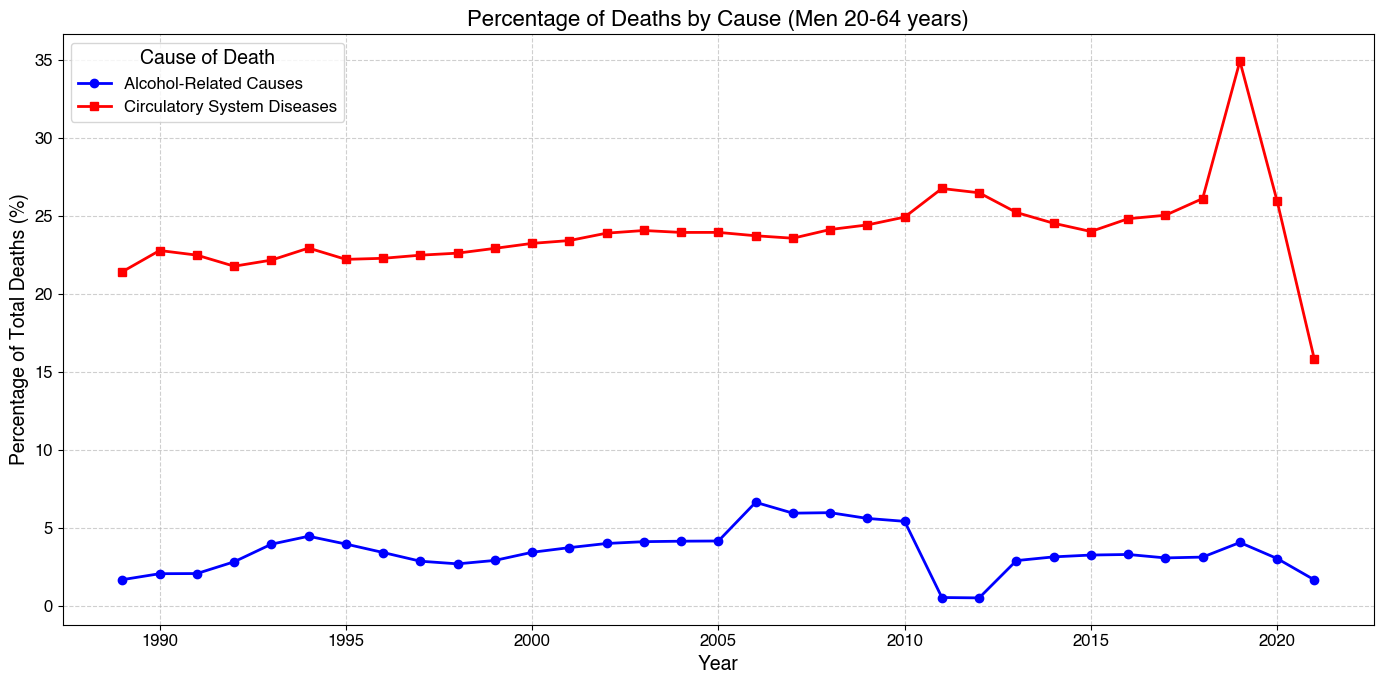

In [84]:
plt.figure(figsize=(14, 7))

# Plot percentage of deaths from alcohol-related causes
plt.plot(df_result['Year'], df_result['Pct_from_alcohol'], label='Alcohol-Related Causes', color='blue', linewidth=2, marker='o')

# Plot percentage of deaths from circulatory system diseases
plt.plot(df_result['Year'], df_result['Pct_from_circulatory'], label='Circulatory System Diseases', color='red', linewidth=2, marker='s')

# Add title and labels with improved styling
plt.title('Percentage of Deaths by Cause (Men 20-64 years)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Percentage of Total Deaths (%)', fontsize=14)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add grid with better visibility
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend with improved styling
plt.legend(title='Cause of Death', fontsize=12, title_fontsize=14, loc='upper left')

# Adjust layout for better spacing
plt.tight_layout()

plt.show()

#### Mortality 1 year age group
We had to combine the dataset with population data so that we can correctly combine the death rates when grouping by regions

In [85]:
# Column name preparation
POP_PREFIX = 'PopDa'
DR_PREFIX = 'Dra'
death_rate_cols = [f"{DR_PREFIX}{age}" for age in age_considered]
pop_cols = [f"{POP_PREFIX}{age}" for age in age_considered]
columns = ['Year', 'Reg', 'Group', 'Sex'] + death_rate_cols + pop_cols
age_considered = range(18, 66)

In [86]:
# Load population data
df_pop1 = pd.read_csv('data/mortality_data/PopDa1989-2014.txt', dtype={'Year': int})
df_pop1 = df_pop1[df_pop1['Year'] < 2012]
df_pop2 = pd.read_csv('data/mortality_data/PopDa2012-2022.txt')
df_pop = pd.concat([df_pop1, df_pop2], ignore_index=True)

In [87]:
# Load mortality data
df1 = pd.read_csv('data/mortality_data/DRa1989-2014.txt')
df2 = pd.read_csv('data/mortality_data/DRa2012-2022.txt')
df1 = df1[df1['Year'] <  2012]
df = pd.concat([df1, df2], ignore_index=True)

# Filter for working age group 'T'
df_group_t = df[df['Group'] == 'T']
df_pop_group_t = df_pop[df_pop['Group'] == 'T']
# Merge mortality and population data
df_merged = pd.merge(
    df_group_t,
    df_pop_group_t,
    on=['Year', 'Reg', 'Group', 'Sex'],
    suffixes=('_mortality', '_population'),
)

# Keep only relevant columns
df_merged = df_merged[['Year', 'Reg', 'Group', 'Sex'] + death_rate_cols + pop_cols]

# Convert death rate and population columns to numeric
df_merged[death_rate_cols] = df_merged[death_rate_cols].apply(pd.to_numeric, errors='coerce')
df_merged[pop_cols] = df_merged[pop_cols].apply(pd.to_numeric, errors='coerce')

In [88]:
# Compute weighted average death rates
def calculate_weighted_average(group):
    weighted_totals = []
    for dr_col, pop_col in zip(death_rate_cols, pop_cols):
        dr = group[dr_col]
        pop = group[pop_col]
        weighted_sum = (dr * pop).sum()
        total_pop = pop.sum()
        avg = weighted_sum / total_pop if total_pop > 0 else 0
        weighted_totals.append(avg)
    return pd.Series(weighted_totals, index=[f"TotalDra{age}" for age in age_considered])

# Apply the calculation grouped by Year and Sex
df_grouped = df_merged.groupby(['Year', 'Sex']).apply(calculate_weighted_average).reset_index()

# Display results
# Convert death rates from per 1,000,000 to per 1,000 population
death_rate_output_cols = [f"TotalDra{age}" for age in age_considered]
df_grouped[death_rate_output_cols] = df_grouped[death_rate_output_cols] / 1000

# Display results
df_grouped.head()

ValueError: Length of values (9) does not match length of index (48)

In [ ]:
df_grouped['AverageDeathRate'] = df_grouped[[f"TotalDra{age}" for age in age_considered]].mean(axis=1)

pivot_df = df_grouped.pivot(index='Year', columns='Sex', values='AverageDeathRate')

plt.figure(figsize=(12, 6))

if 'M' in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df['M'], label='Men', color='tab:blue', linewidth=1.5)

if 'F' in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df['F'], label='Women', color='tab:red', linewidth=1.5)

# Add labels, title, and legend
plt.title('Average Death Rates in Russia (Ages 18-65)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Death Rate per 1,000 population')
plt.legend(loc='upper right', title='Gender')
plt.grid(True, linestyle='--', alpha=0.7, color='gray')

plt.show()

### Alcohol consumption per capita, WHO
The dataset is of good quality and we only had to map the column names to more useable names, as they were very cryptic (e.g. Dim1 was actually just the beverage type). 

In [ ]:
# Dataset already contains only Russia
df_alco_raw = pd.read_csv('data/consumption_by_beverage.csv')
column_mapping = {
    "Period": "Year",                # Year of the data
    "SpatialDimValueCode": "CountryCode",  # Country code
    "Dim1": "BeverageType",          # Type of beverage
    "FactValueNumeric": "Value"      # Value of alcohol consumption
}
df_alco = df_alco_raw[column_mapping.keys()].copy()
df_alco.rename(columns=column_mapping, inplace=True)

The dataset covers years from 1963 to 2020. It contains 4 main beverage types: beer, wine, spirits and other.

In [ ]:
df_alco.head()

In [ ]:
# Years
df_alco['Year'].unique()

In [ ]:
# Get unique beverage types
df_alco['BeverageType'].unique()

In [ ]:
beverage_consumption = df_alco.groupby(['BeverageType', 'Year'])['Value'].sum().unstack('BeverageType')
beverage_consumption.plot(kind='line', title='Alcohol Consumption by Beverage Type Over Time', ylabel='Liters per Capita')
plt.legend(title='Beverage Type')
plt.show()

### Life expectancy dataset
This was already a cleaned and processed dataset so we did not have to do anything before the analysis. The dataset covers 290 countries or regions, it spans from 1950 to 2023. Russia life expectancy for men lower then the world average in recent years. Life expectancy for women much higher.

In [ ]:
df_life_expectancy = pd.read_csv('data/life_expectancy/life-expectancy-of-women-vs-life-expectancy-of-men.csv')

df_life_expectancy.head()

In [ ]:
print(f"Dataset contains {df_life_expectancy['Entity'].unique().size} countries or regions.")

In [ ]:
df_life_expectancy['Year'].unique()

In [ ]:
# Create a pivot table for easier plotting
# Define the selected countries
selected_countries = ['United States', 'Russia', 'Denmark', 'China', 'Belarus', 'World']
df_selected = df_life_expectancy[df_life_expectancy['Entity'].isin(selected_countries)]
pivot_life_expectancy = df_selected.pivot(index='Year', columns='Entity', values=[
    'Life expectancy - Sex: female - Age: 0 - Variant: estimates',
    'Life expectancy - Sex: male - Age: 0 - Variant: estimates'
])

# Plot life expectancy for men and women
plt.figure(figsize=(12, 8))
for country in selected_countries:
    plt.plot(
        pivot_life_expectancy.index,
        pivot_life_expectancy['Life expectancy - Sex: female - Age: 0 - Variant: estimates'][country],
        label=f'{country} - Female'
    )
    plt.plot(
        pivot_life_expectancy.index,
        pivot_life_expectancy['Life expectancy - Sex: male - Age: 0 - Variant: estimates'][country],
        label=f'{country} - Male',
        linestyle='--'
    )

plt.title('Life Expectancy Comparison Between Men and Women')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (Years)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Data Analysis

We used the Global Burden of Disease (GBD) 2021 dataset to understand alcohol-related mortality trends in Russia and compare them to the rest of the world. The GBD data was filtered to focus on causes that are explicitly linked to alcohol which were: alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use. Then we looked at the values for YLLs (Years of Life Lost) and death for all countries during the period we wanted to investigate (1990-2021). Russia had the highest alcohol related mortality and YYLs each year with the few countries coming close to it also being from Eastern Europe. 

# 4. Genre. Which genre of data story did you use?
Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?
Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?


# 5. Visualizations.

A simple lineplot was decided to be the best way to showcase the higher alcohol-related mortality in Russia compared to the rest of the world. Since Russia had the highest mortality of all, with some Eastern Euroean counries coming close, we decided to include one country from the same region, Belarus, and four others were randomly selected: China, Denmark, France, The United States of America. We wanted this plot to convey that alcohol related deaths in Russia stand out in two ways, they are a lot more common than elsewhere and the mortality rate has gone through a lot of swings in the past 30 years.

To highlight the gender disparity in alcohol-related mortality, a stacked area chart displaying Years of Life Lost (YLLs) in Russia from 1990 to 2021, stratified by sex, was used. It covers four alcohol-related causes of death: alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use. The y-axis shows the total YLLs in millions. The two colored areas separate the male and female contributions to alcohol-related premature mortality over time. This well supports our story's narrative which includes making the gender disparity in alcohol-related mortality visible. The much larger area for men visually reinforces that Russian men bear a disproportionate burden of premature death due to alcohol. 


# 6. Discussion. Think critically about your creation
What went well?,
What is still missing? What could be improved?, Why?


# 7. Contributions. Who did what?
You should write (just briefly) which group member was the main responsible for which elements of the assignment. (I want you guys to understand every part of the assignment, but usually there is someone who took lead role on certain portions of the work. That's what you should explain).